# 📗 S2_P1T — Notebook SOLUTION : le pipeline complet sur l'EEG

Ce notebook est la **correction complète** de l'exercice EEG (S5_P1) : exploration → split → 3 modèles (LogisticRegression, KNN avec recherche du meilleur k, arbre de décision) → tableau comparatif. Chaque étape reprend les patterns vus en S2-S4.

---
**Étape 1 — Charger et explorer** : imports + lecture du CSV.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../Data/EEG-Eye-State.csv")
df

,AF3,AF4,F3,F4,F7,F8,FC5,FC6,T7,T8,P7,P8,O1,O2,eyeDetection
0,4329.23,4393.85,4289.23,4280.51,4009.23,4635.90,4148.21,4211.28,4350.26,4238.46,4586.15,4222.05,4096.92,4641.03,0
1,4324.62,4384.10,4293.85,4279.49,4004.62,4632.82,4148.72,4207.69,4342.05,4226.67,4586.67,4210.77,4097.44,4638.97,0
2,4327.69,4389.23,4295.38,4282.05,4006.67,4628.72,4156.41,4206.67,4336.92,4222.05,4583.59,4207.69,4096.92,4630.26,0
3,4328.72,4396.41,4296.41,4287.69,4011.79,4632.31,4155.90,4210.77,4343.59,4235.38,4582.56,4217.44,4097.44,4630.77,0
4,4326.15,4398.46,4292.31,4288.21,4011.79,4632.82,4151.28,4212.82,4347.69,4244.10,4586.67,4210.77,4095.90,4627.69,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14975,4281.03,4340.51,4245.64,4269.23,3990.26,4593.33,4116.92,4171.28,4333.85,4221.54,4614.36,4203.08,4074.87,4625.64,1
14976,4276.92,4333.33,4245.13,4259.49,3991.79,4590.26,4110.77,4162.56,4332.82,4217.44,4615.38,4194.36,4073.33,4621.54,1
14977,4277.44,4339.49,4246.67,4257.95,3990.77,4591.79,4113.85,4160.51,4333.33,4212.82,4615.38,4193.33,4072.82,4623.59,1
14978,4284.62,4350.77,4251.28,4267.18,3991.79,4596.41,4122.05,4165.64,4334.36,4220.00,4616.41,4200.00,4080.51,4628.72,1


In [2]:
df.columns

Index(['AF3', 'AF4', 'F3', 'F4', 'F7', 'F8', 'FC5', 'FC6', 'T7', 'T8', 'P7',
       'P8', 'O1', 'O2', 'eyeDetection'],
      dtype='str')

In [3]:
df.isna().sum()

AF3             0
AF4             0
F3              0
F4              0
F7              0
F8              0
FC5             0
FC6             0
T7              0
T8              0
P7              0
P8              0
O1              0
O2              0
eyeDetection    0
dtype: int64

In [4]:
df.describe()

,AF3,AF4,F3,F4,F7,F8,FC5,FC6,T7,T8,P7,P8,O1,O2,eyeDetection
count,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000
mean,4321.917777,4416.435832,4264.022433,4279.232774,4009.767694,4615.205336,4164.946326,4202.456900,4341.741075,4231.316200,4644.022379,4218.826610,4110.400160,4616.056904,0.448798
std,2492.072174,5891.285043,44.428052,41.544312,45.941672,1208.369958,5216.404632,37.785981,34.738821,38.050903,2924.789537,2136.408523,4600.926543,29.292603,0.497388
min,1030.770000,1366.150000,1040.000000,2257.950000,2830.770000,86.666700,2453.330000,3273.330000,2089.740000,1816.410000,2768.210000,1357.950000,2086.150000,4567.180000,0.000000
25%,4280.510000,4342.050000,4250.260000,4267.690000,3990.770000,4590.770000,4108.210000,4190.260000,4331.790000,4220.510000,4611.790000,4190.770000,4057.950000,4604.620000,0.000000
50%,4294.360000,4354.870000,4262.560000,4276.920000,4005.640000,4603.080000,4120.510000,4200.510000,4338.970000,4229.230000,4617.950000,4199.490000,4070.260000,4613.330000,0.000000
75%,4311.790000,4372.820000,4270.770000,4287.180000,4023.080000,4617.440000,4132.310000,4211.280000,4347.180000,4239.490000,4626.670000,4209.230000,4083.590000,4624.100000,1.000000
max,309231.000000,715897.000000,6880.510000,7002.560000,7804.620000,152308.000000,642564.000000,6823.080000,6474.360000,6674.360000,362564.000000,265641.000000,567179.000000,7264.100000,1.000000


In [5]:
df["eyeDetection"].value_counts()

eyeDetection
0    8257
1    6723
Name: count, dtype: int64

**Étape 2 — Répartition de la cible** : 8 257 « œil ouvert » (0) / 6 723 « fermé » (1) — déséquilibre léger (55/45), l'accuracy reste utilisable. Baseline à battre : 55 %.

In [6]:
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(df, test_size=0.2, random_state=32)

**Étape 3 — Split PROPRE** : sur le df complet, puis X/y par `drop("eyeDetection")` — l'ordre correct (contrairement aux deux bugs historiques de S5_P1 !).

In [7]:
X_train = train_data.drop("eyeDetection", axis=1)
y_train = train_data["eyeDetection"]
X_test = test_data.drop("eyeDetection", axis=1)
y_test = test_data["eyeDetection"]

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, balanced_accuracy_score, accuracy_score

In [9]:
LR = LogisticRegression(max_iter=1000)
LR.fit(X_train, y_train)
y_pred_lr = LR.predict(X_test)

**Étape 4 — Régression logistique** : `max_iter=1000` pour laisser l'optimiseur converger malgré les échelles disparates (sans standardisation). Résultat modeste attendu (~0.64) : les outliers massifs du describe() pénalisent le modèle linéaire.

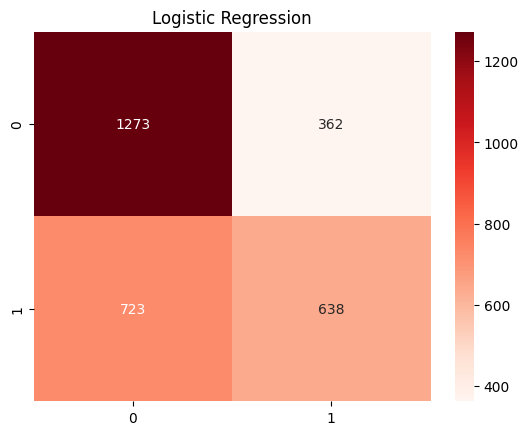

In [10]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, cmap="Reds", fmt="d")
plt.title("Logistic Regression")
plt.show()

In [11]:
print(classification_report(y_test, y_pred_lr))
print("Balanced accuracy:", balanced_accuracy_score(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.64      0.78      0.70      1635
           1       0.64      0.47      0.54      1361

    accuracy                           0.64      2996
   macro avg       0.64      0.62      0.62      2996
weighted avg       0.64      0.64      0.63      2996

Balanced accuracy: 0.6236831166146497


In [12]:
from sklearn.neighbors import KNeighborsClassifier

accuracy = []
list_k = []
for k in range(1, 31):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred_k = knn.predict(X_test)
    list_k.append(k)
    accuracy.append(accuracy_score(y_test, y_pred_k))

**Étape 5 — Recherche du meilleur k** : boucle 1→30, courbe accuracy-vs-k, et `metrics_df.loc[df["Acc"].idxmax(), "K"]` — la façon SÛRE de lire le meilleur k (pas le piège idxmin/idxmax de S4_P1 !).

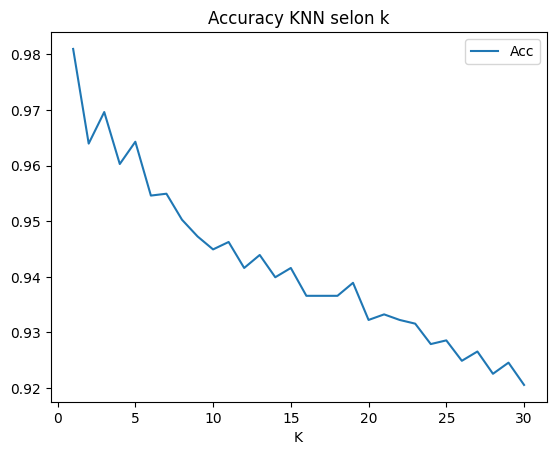

Meilleur k : 1


In [13]:
metrics_df = pd.DataFrame({"K": list_k, "Acc": accuracy})
metrics_df.plot(x="K", y="Acc")
plt.title("Accuracy KNN selon k")
plt.show()

best_k = metrics_df.loc[metrics_df["Acc"].idxmax(), "K"]
print("Meilleur k :", best_k)

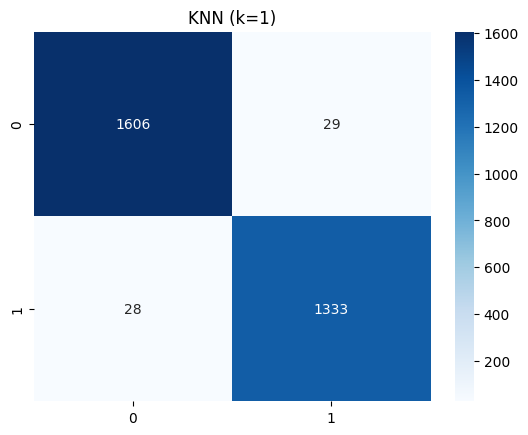

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1635
           1       0.98      0.98      0.98      1361

    accuracy                           0.98      2996
   macro avg       0.98      0.98      0.98      2996
weighted avg       0.98      0.98      0.98      2996

Balanced accuracy: 0.9808449444665395


In [14]:
knn = KNeighborsClassifier(n_neighbors=int(best_k))
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

cm_knn = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm_knn, annot=True, cmap="Blues", fmt="d")
plt.title(f"KNN (k={best_k})")
plt.show()

print(classification_report(y_test, y_pred_knn))
print("Balanced accuracy:", balanced_accuracy_score(y_test, y_pred_knn))

**Étape 6 — KNN final (k=1, ≈0.98)** — ⚠️ score dopé par la **fuite temporelle** : mesures consécutives quasi identiques réparties entre train et test par le mélange aléatoire. Sur une série temporelle, il faudrait découper par blocs de temps. Un 98 % doit toujours éveiller le soupçon !

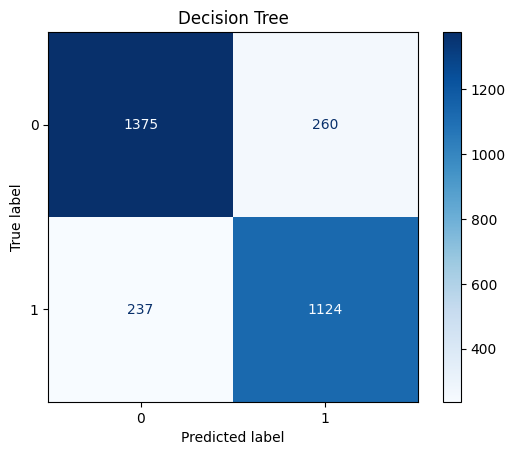

              precision    recall  f1-score   support

           0       0.85      0.84      0.85      1635
           1       0.81      0.83      0.82      1361

    accuracy                           0.83      2996
   macro avg       0.83      0.83      0.83      2996
weighted avg       0.83      0.83      0.83      2996

Balanced accuracy: 0.833420964527342


In [19]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

dt = DecisionTreeClassifier(random_state=32)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

cm_dt = confusion_matrix(y_test, y_pred_dt)
ConfusionMatrixDisplay(cm_dt).plot(cmap="Blues")
plt.title("Decision Tree")
plt.show()

print(classification_report(y_test, y_pred_dt))
print("Balanced accuracy:", balanced_accuracy_score(y_test, y_pred_dt))

**Étape 7 — Arbre de décision** (~0.83) + importances : quels capteurs (électrodes) discriminent le mieux l'état de l'œil — O1 et P7 (zone occipitale/pariétale, proche du cortex visuel !) ressortent en tête.

In [16]:
importances = pd.DataFrame({"feature": X_train.columns, "importance": dt.feature_importances_})
importances = importances.sort_values("importance", ascending=False)
importances

,feature,importance
10,P7,0.135648
12,O1,0.128729
4,F7,0.100041
5,F8,0.084721
1,AF4,0.073378
8,T7,0.063008
0,AF3,0.062111
2,F3,0.061716
3,F4,0.054393
7,FC6,0.052944


In [17]:
resultats = pd.DataFrame({
    "Modele": ["LogisticRegression", f"KNN (k={best_k})", "DecisionTree"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_dt),
    ],
    "BalancedAccuracy": [
        balanced_accuracy_score(y_test, y_pred_lr),
        balanced_accuracy_score(y_test, y_pred_knn),
        balanced_accuracy_score(y_test, y_pred_dt),
    ],
})
resultats

,Modele,Accuracy,BalancedAccuracy
0,LogisticRegression,0.637850,0.623683
1,KNN (k=1),0.980975,0.980845
2,DecisionTree,0.834112,0.833421


**Étape 8 — Le verdict** : tableau comparatif des 3 modèles (accuracy + balanced accuracy). KNN 0.98 (à relativiser — leakage), arbre 0.83, LR 0.64. Toujours finir par une comparaison chiffrée sur le MÊME test set.